# HealthConnect Clinic — Week 5 Initial Analytics Report
**Track:** Data Analytics | **Programme:** AnalystLab Africa Experience Lab
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

Week 5 moves from Week 4's planning (business questions, candidate KPIs, data quality review) into full exploratory analysis, KPI calculation, dashboard visualisation and business insight generation.

The original `HealthConnect_Appointment_Data.csv` is read only and never overwritten. Derived columns used throughout this notebook are saved separately to `HealthConnect_Appointment_Data_processed.csv`.

## 0. Week 4 → Week 5 Transition

**Problem defined in Week 4:** understand the appointment dataset and identify how it can be used to investigate appointment attendance and no-show patterns.

**Week 4 proposed approach:** segment deep-dive on the five candidate KPIs, statistical grounding via chi-square testing, cross-tabulation of combined effects, a slot-utilisation angle (no-shows vs. cancellations), and hand-off of segments to the Data Science track.

**Resources used:** `HealthConnect_Appointment_Data.csv`, `HealthConnect_Data_Dictionary.xlsx`, and the HealthConnect Clinic Knowledge Base (for the Sunday-appointment cross-check).

**Key Week 4 assumptions/limitations carried forward:** the dataset is synthetic; the Sunday appointment flag (737 records) remains unresolved pending stakeholder clarification; distance and waiting-time missingness (<2% each) was left unimputed; all relationships are correlational, not causal.

**Week 5 plan (as proposed in Week 4):** execute exactly the approach above — this notebook delivers on all five points.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

df = pd.read_csv('HealthConnect_Appointment_Data.csv', parse_dates=['booking_date', 'appointment_date'])
df.shape

(5000, 18)

## 1. Data Preparation

In [2]:
df.dtypes

appointment_id                      str
patient_id                          str
gender                              str
age                               int64
age_group                           str
appointment_type                    str
booking_date             datetime64[us]
appointment_date         datetime64[us]
appointment_day                     str
appointment_time                    str
booking_lead_days                 int64
previous_appointments             int64
previous_no_shows                 int64
reminder_sent                       str
reminder_channel                    str
distance_to_clinic_km           float64
waiting_time_minutes            float64
appointment_outcome                 str
dtype: object

In [3]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate appointment_id:", df['appointment_id'].duplicated().sum())

Missing values:
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64

Duplicate rows: 0
Duplicate appointment_id: 0


In [4]:
# Inconsistent-value checks (carried over and re-confirmed from Week 4)
checks = {
    'Negative booking_lead_days': (df['booking_lead_days'] < 0).sum(),
    'appointment_date before booking_date': (df['appointment_date'] < df['booking_date']).sum(),
    'previous_no_shows > previous_appointments': (df['previous_no_shows'] > df['previous_appointments']).sum(),
    'Age below 18': (df['age'] < 18).sum(),
    'Negative distance_to_clinic_km': (df['distance_to_clinic_km'] < 0).sum(),
    'Negative waiting_time_minutes': (df['waiting_time_minutes'] < 0).sum(),
    'reminder_sent=No but channel present': ((df['reminder_sent'] == 'No') & (df['reminder_channel'].notnull())).sum(),
}
pd.Series(checks, name='count')

Negative booking_lead_days                   0
appointment_date before booking_date         0
previous_no_shows > previous_appointments    0
Age below 18                                 0
Negative distance_to_clinic_km               0
Negative waiting_time_minutes                0
reminder_sent=No but channel present         0
Name: count, dtype: int64

**Data quality observations (Week 5 confirmation):**
- No duplicates, no invalid negative values, no logically impossible combinations — dataset remains clean.
- `reminder_channel` missing (27.3%) is structural (tied to `reminder_sent = No`), not a defect.
- `distance_to_clinic_km` (1.8%) and `waiting_time_minutes` (1.2%) missingness is minor and left as-is (row-wise excluded only in the specific cuts that use those fields).
- The Sunday-appointment flag (737 records, 14.7%) identified in Week 4 remains unresolved — still treated as a dataset artifact, not corrected, pending clarification from AnalystLab/clinic stakeholders.

In [5]:
# Derived features for analysis - saved separately, original file untouched
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1, 7, 14, 30, 60],
                            labels=['0-7', '8-14', '15-30', '31-60'])
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1, 0, 1, 2, 10],
                                   labels=['0', '1', '2', '3+'])
df['dist_bucket'] = pd.cut(df['distance_to_clinic_km'], bins=[0, 5, 10, 20, 50],
                            labels=['0-5 km', '5-10 km', '10-20 km', '20+ km'])
df['risk_tier'] = np.where(df['prev_noshow_bucket'].isin(['2', '3+']),
                            'Higher-risk (2+ prior no-shows)', 'Lower-risk (0-1 prior no-shows)')

df.to_csv('HealthConnect_Appointment_Data_processed.csv', index=False)
print("Processed dataset saved with", df.shape[1], "columns (4 derived columns added).")

Processed dataset saved with 22 columns (4 derived columns added).


## 2. Exploratory Data Analysis

### 2.1 Appointment characteristics

In [6]:
for col in ['appointment_type', 'appointment_day', 'appointment_time']:
    print(f"--- No-show rate by {col} ---")
    print(df.groupby(col)['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2))
    print()

--- No-show rate by appointment_type ---
appointment_type
Diagnostic Test            49.75
Follow-up                  51.23
General Consultation       46.64
Specialist Consultation    47.44
Name: appointment_outcome, dtype: float64

--- No-show rate by appointment_day ---
appointment_day
Friday       46.57
Monday       49.64
Saturday     46.82
Sunday       50.47
Thursday     48.98
Tuesday      47.02
Wednesday    49.66
Name: appointment_outcome, dtype: float64

--- No-show rate by appointment_time ---
appointment_time
Afternoon    48.38
Evening      49.78
Morning      48.14
Name: appointment_outcome, dtype: float64



**Observation:** appointment type, day of week and time of day all show no-show rates within a few points of the ~48% baseline — none stand out as a strong standalone driver.

### 2.2 Patient characteristics

In [7]:
for col in ['gender', 'age_group']:
    print(f"--- No-show rate by {col} ---")
    print(df.groupby(col)['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2))
    print()

--- No-show rate by gender ---
gender
Female               48.43
Male                 48.71
Prefer not to say    43.52
Name: appointment_outcome, dtype: float64

--- No-show rate by age_group ---
age_group
18-24    50.18
25-34    50.70
35-44    48.35
45-54    48.05
55-64    50.75
65+      45.12
Name: appointment_outcome, dtype: float64



**Observation:** gender and age group show minimal variation — patient demographics alone are weak predictors of attendance in this dataset.

### 2.3 Previous appointment history

In [8]:
hist_rate = df.groupby('prev_noshow_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2)
ct_hist = pd.crosstab(df['prev_noshow_bucket'], df['appointment_outcome'])
chi2_h, p_h, _, _ = chi2_contingency(ct_hist)
print(hist_rate)
print(f"\nChi-square: {chi2_h:.2f}, p-value: {p_h:.2e}")

prev_noshow_bucket
0     43.51
1     53.49
2     59.36
3+    68.82
Name: appointment_outcome, dtype: float64

Chi-square: 82.00, p-value: 1.38e-15


**Observation:** a strong, statistically significant relationship (p < 0.001). No-show rate rises from 43.5% (no prior no-shows) to 68.8% (3+ prior no-shows).

### 2.4 Reminders

In [9]:
rem_rate = df.groupby('reminder_sent')['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2)
ct_rem = pd.crosstab(df['reminder_sent'], df['appointment_outcome'])
chi2_r, p_r, _, _ = chi2_contingency(ct_rem)
print(rem_rate)
print(f"\nChi-square: {chi2_r:.2f}, p-value: {p_r:.4f}")

channel_rate = df.groupby('reminder_channel')['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2)
print("\nBy channel:\n", channel_rate)

reminder_sent
No     51.39
Yes    47.36
Name: appointment_outcome, dtype: float64

Chi-square: 10.20, p-value: 0.0061

By channel:
 reminder_channel
Email       48.41
SMS         45.75
WhatsApp    49.77
Name: appointment_outcome, dtype: float64


In [10]:
# Does the reminder effect differ by risk tier?
rem_by_risk = df.groupby(['risk_tier', 'reminder_sent'])['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(1).unstack()
rem_by_risk

reminder_sent,No,Yes
risk_tier,,
Higher-risk (2+ prior no-shows),68.2,58.2
Lower-risk (0-1 prior no-shows),49.3,46.1


**Observation:** the overall reminder effect is small but statistically significant (p ≈ 0.006). Critically, the effect is far from uniform — among higher-risk patients (2+ prior no-shows) a reminder drops the no-show rate by ~10 points (68.2% → 58.2%), while for lower-risk patients the drop is only ~3 points (49.3% → 46.1%). Reminders appear to matter most exactly where they're needed most.

### 2.5 Waiting time

In [11]:
df.groupby('appointment_outcome')['waiting_time_minutes'].describe()[['mean', '50%', 'std']]

,mean,50%,std
appointment_outcome,,,
Attended,24.289141,24.0,10.946389
Cancelled,23.214559,22.0,10.557896
No-Show,24.200754,24.0,10.814945


**Observation:** average waiting time is nearly identical across Attended, No-Show and Cancelled groups (~23-24 minutes). Waiting time (recorded for the appointment itself) does not show a meaningful relationship with the outcome in this dataset.

### 2.6 Distance to clinic

In [12]:
dist_rate = df.groupby('dist_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2)
ct_dist = pd.crosstab(df['dist_bucket'], df['appointment_outcome'])
chi2_d, p_d, _, _ = chi2_contingency(ct_dist)
print(dist_rate)
print(f"\nChi-square: {chi2_d:.2f}, p-value: {p_d:.4f}")

dist_bucket
0-5 km      46.45
5-10 km     46.51
10-20 km    49.43
20+ km      57.76
Name: appointment_outcome, dtype: float64

Chi-square: 21.18, p-value: 0.0017


**Observation:** statistically significant (p ≈ 0.0017). No-show rate is flat under 20km (~46-47%) but rises to 57.8% for patients 20km+ from the clinic.

### 2.7 Cancellations vs no-shows — slot utilisation

In [13]:
outcome_counts = df['appointment_outcome'].value_counts()
lost_pct = (outcome_counts['No-Show'] + outcome_counts['Cancelled']) / len(df) * 100
print(outcome_counts)
print(f"\nTotal appointment slots not used as booked (No-Show + Cancelled): {lost_pct:.1f}%")

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Total appointment slots not used as booked (No-Show + Cancelled): 53.7%


**Observation:** over half of all scheduled slots (53.7%) are never used as originally booked. Cancellations (5.3%) are a much smaller share than no-shows (48.5%), but unlike no-shows, a cancellation at least gives the clinic advance notice to potentially rebook the slot — no-shows offer no such opportunity.

### 2.8 Compounding effect: lead time × prior no-show history

In [14]:
pivot = df.pivot_table(index='prev_noshow_bucket', columns='lead_bucket', values='appointment_outcome',
                        aggfunc=lambda x: (x == 'No-Show').mean() * 100, observed=True)
pivot.round(1)

lead_bucket,0-7,8-14,15-30,31-60
prev_noshow_bucket,,,,
0,21.8,31.6,38.4,55.2
1,33.2,31.8,46.8,66.4
2,49.2,45.8,52.8,71.2
3+,20.0,60.0,80.8,81.0


**Observation:** the two strongest individual drivers compound sharply. Patients with 3+ prior no-shows booked 15-30 or 31-60 days out reach an 80-81% no-show rate — by far the highest-risk segment in the dataset — while patients with a clean history booked within a week sit at just 22%.

## 3. KPI Development

Five KPIs were proposed in Week 4; all five are calculated and interpreted below, each tied to its business question.

### KPI 1 — Overall No-Show Rate

In [15]:
overall_rate = (df['appointment_outcome'] == 'No-Show').mean() * 100
print(f"Overall No-Show Rate: {overall_rate:.2f}%")

Overall No-Show Rate: 48.46%


**Definition:** the percentage of all scheduled appointments with outcome `No-Show`.
**Why it matters:** it is the single top-line measure of the scale of the problem HealthConnect is trying to solve.
**Business question:** what is the overall scale of the no-show problem, and how is it distributed?
**Result:** 48.46%.
**Interpretation:** essentially one in two scheduled appointments is missed outright — this confirms the problem is large enough to justify dedicated intervention, not just a minor operational nuisance.

### KPI 2 — No-Show Rate by Booking Lead Time Band

In [16]:
lead_rate = df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(lambda x: (x == 'No-Show').mean() * 100).round(2)
lead_rate

lead_bucket
0-7      27.81
8-14     33.55
15-30    43.21
31-60    60.49
Name: appointment_outcome, dtype: float64

**Definition:** no-show rate segmented into four booking-lead-time bands (0-7, 8-14, 15-30, 31-60 days).
**Why it matters:** it identifies whether how far in advance a patient books is itself a risk factor, independent of who the patient is.
**Business question:** does the amount of lead time between booking and the appointment affect the likelihood of a no-show?
**Result:** 27.8% (0-7 days) rising to 60.5% (31-60 days); chi-square = 339.0, p < 0.001.
**Interpretation:** this is the strongest single driver found in the dataset. Appointments booked more than a month out are more than twice as likely to be missed as those booked within a week — a strong candidate for a targeted reminder or reconfirmation policy for far-out bookings.

### KPI 3 — No-Show Rate by Prior No-Show Count

In [17]:
hist_rate

prev_noshow_bucket
0     43.51
1     53.49
2     59.36
3+    68.82
Name: appointment_outcome, dtype: float64

**Definition:** no-show rate segmented by how many previous no-shows a patient has on record (0, 1, 2, 3+).
**Why it matters:** past behaviour is often the best available predictor of future behaviour, and this field is already captured in the dataset.
**Business question:** can a patient's appointment history be used to flag higher-risk future appointments?
**Result:** 43.5% (0 prior) rising to 68.8% (3+ prior); chi-square = 82.0, p < 0.001.
**Interpretation:** a simple, explainable risk rule ("2 or more prior no-shows = higher risk") could be applied immediately, without needing a full predictive model, to prioritise reminder calls or overbooking decisions.

### KPI 4 — Reminder Effectiveness Rate

In [18]:
rem_rate


reminder_sent
No     51.39
Yes    47.36
Name: appointment_outcome, dtype: float64

In [19]:
rem_by_risk

reminder_sent,No,Yes
risk_tier,,
Higher-risk (2+ prior no-shows),68.2,58.2
Lower-risk (0-1 prior no-shows),49.3,46.1


**Definition:** no-show rate compared between appointments where a reminder was sent vs. not sent, and by delivery channel; also examined split by patient risk tier.
**Why it matters:** reminders are a low-cost, easily-scaled intervention — if they work, they're one of the cheapest levers HealthConnect has.
**Business question:** are reminders — and the channel used — associated with a measurable reduction in no-shows?
**Result:** 47.4% (reminder sent) vs. 51.4% (no reminder) overall, chi-square = 10.2, p ≈ 0.006 — statistically significant but modest. Split by risk tier: higher-risk patients see a ~10-point drop (68.2% → 58.2%) vs. only ~3 points for lower-risk patients (49.3% → 46.1%). SMS shows the lowest no-show rate among channels (45.75%).
**Interpretation:** blanket reminders have a real but limited effect; reminders appear far more valuable for higher-risk patients specifically. This reframes the business question from "do reminders work?" to "who should get the most reminder effort?"—a much more actionable framing for HealthConnect.

### KPI 5 — No-Show Rate by Distance Band

In [20]:
dist_rate

dist_bucket
0-5 km      46.45
5-10 km     46.51
10-20 km    49.43
20+ km      57.76
Name: appointment_outcome, dtype: float64

**Definition:** no-show rate segmented into four distance-to-clinic bands (0-5, 5-10, 10-20, 20+ km).
**Why it matters:** if distance is a real barrier, it points to structural fixes (telehealth options, transport support) rather than behavioural ones (reminders).
**Business question:** does distance to the clinic influence attendance, and could this inform outreach or scheduling decisions?
**Result:** roughly flat under 20km (46-47%), rising to 57.8% at 20km+; chi-square = 21.2, p ≈ 0.0017.
**Interpretation:** distance is not a broad driver but a threshold effect — patients beyond ~20km face a meaningfully higher barrier, making them a plausible target for remote/telehealth follow-up options rather than more reminders alone.

## 4. Dashboard

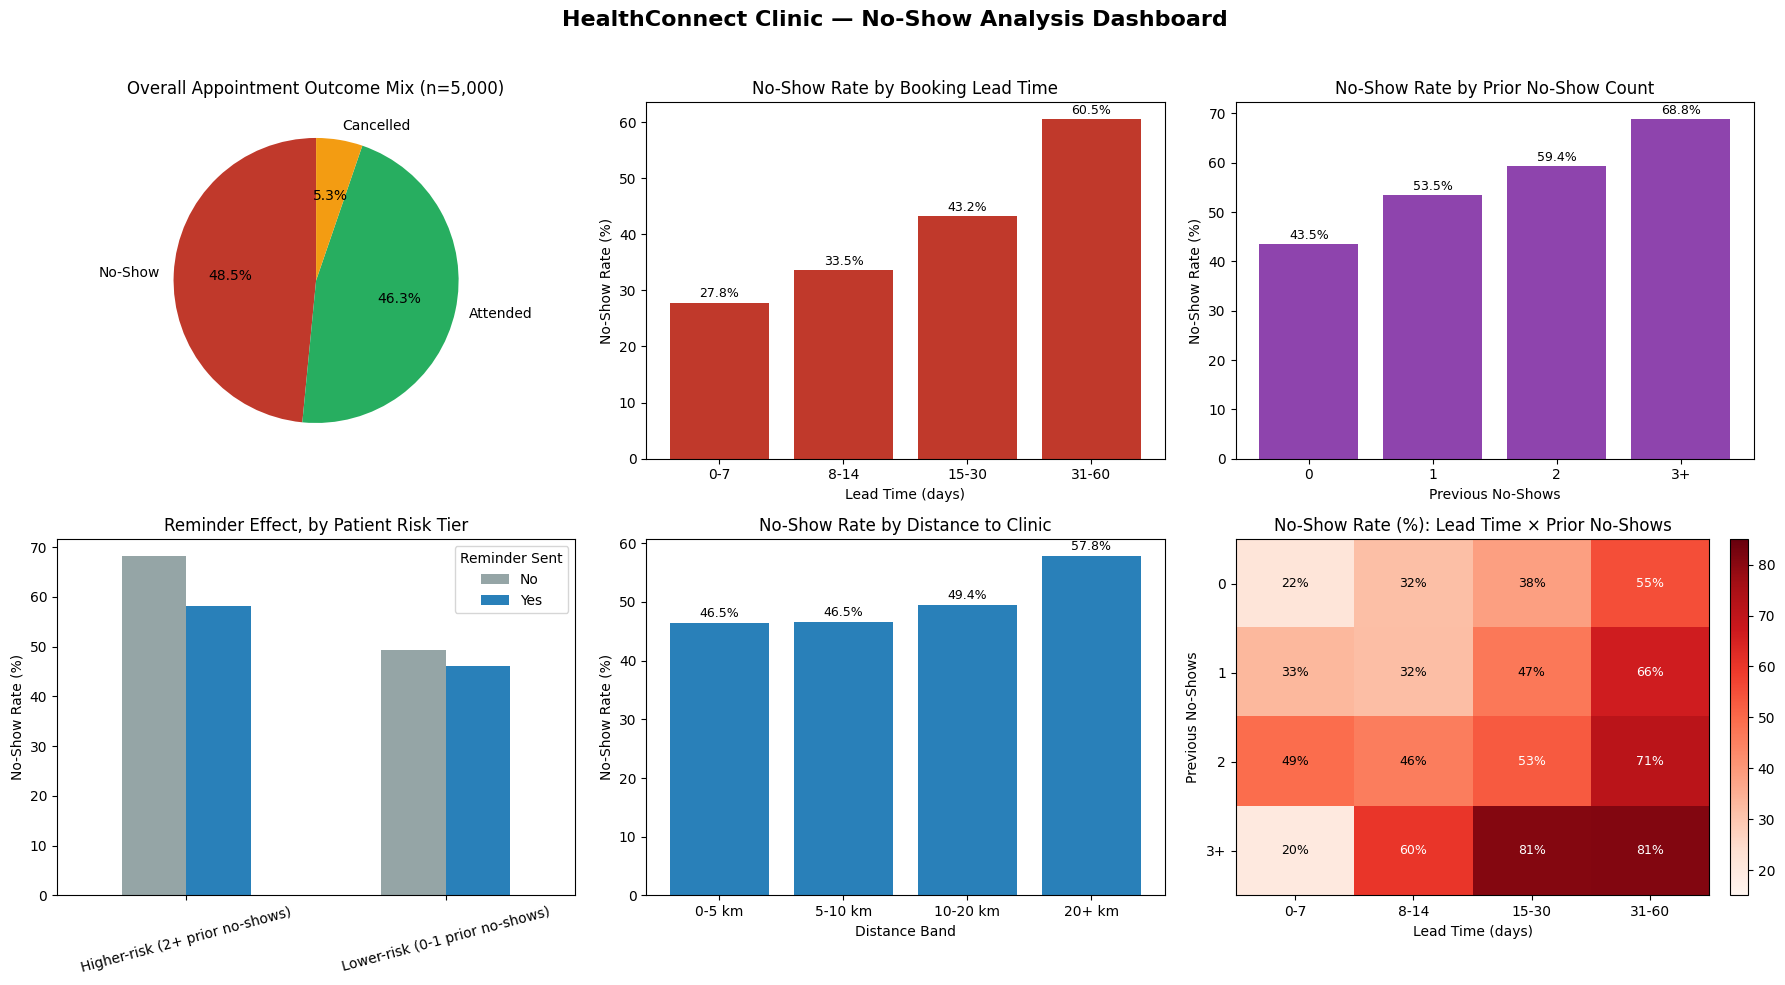

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HealthConnect Clinic — No-Show Analysis Dashboard', fontsize=16, fontweight='bold')

outcome_counts = df['appointment_outcome'].value_counts()
axes[0, 0].pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%',
               colors=['#c0392b', '#27ae60', '#f39c12'], startangle=90)
axes[0, 0].set_title('Overall Appointment Outcome Mix (n=5,000)')

axes[0, 1].bar(lead_rate.index.astype(str), lead_rate.values, color='#c0392b')
axes[0, 1].set_title('No-Show Rate by Booking Lead Time')
axes[0, 1].set_ylabel('No-Show Rate (%)'); axes[0, 1].set_xlabel('Lead Time (days)')
for i, v in enumerate(lead_rate.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

axes[0, 2].bar(hist_rate.index.astype(str), hist_rate.values, color='#8e44ad')
axes[0, 2].set_title('No-Show Rate by Prior No-Show Count')
axes[0, 2].set_ylabel('No-Show Rate (%)'); axes[0, 2].set_xlabel('Previous No-Shows')
for i, v in enumerate(hist_rate.values):
    axes[0, 2].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

rem_by_risk[['No', 'Yes']].plot(kind='bar', ax=axes[1, 0], color=['#95a5a6', '#2980b9'])
axes[1, 0].set_title('Reminder Effect, by Patient Risk Tier')
axes[1, 0].set_ylabel('No-Show Rate (%)'); axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=15); axes[1, 0].legend(title='Reminder Sent')

axes[1, 1].bar(dist_rate.index.astype(str), dist_rate.values, color='#2980b9')
axes[1, 1].set_title('No-Show Rate by Distance to Clinic')
axes[1, 1].set_ylabel('No-Show Rate (%)'); axes[1, 1].set_xlabel('Distance Band')
for i, v in enumerate(dist_rate.values):
    axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

im = axes[1, 2].imshow(pivot.values, cmap='Reds', vmin=15, vmax=85, aspect='auto')
axes[1, 2].set_xticks(range(len(pivot.columns))); axes[1, 2].set_xticklabels(pivot.columns)
axes[1, 2].set_yticks(range(len(pivot.index))); axes[1, 2].set_yticklabels(pivot.index)
axes[1, 2].set_title('No-Show Rate (%): Lead Time × Prior No-Shows')
axes[1, 2].set_xlabel('Lead Time (days)'); axes[1, 2].set_ylabel('Previous No-Shows')
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        axes[1, 2].text(j, i, f'{val:.0f}%', ha='center', va='center',
                         color='white' if val > 50 else 'black', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 5. Business Insights

1. **The problem is large and material.** Nearly half of all appointments (48.5%) end in a no-show, and combined with cancellations, 53.7% of scheduled slots are never used as booked — this represents a major capacity and revenue leakage opportunity, not a minor operational nuisance.
2. **Booking lead time is the single strongest, most statistically significant driver found** (chi-square = 339.0, p < 0.001). No-show rate more than doubles from 27.8% (booked within a week) to 60.5% (booked 31-60 days out) — suggesting reconfirmation touchpoints for far-out bookings would be high-value.
3. **Patient history is a ready-made, low-cost risk signal.** Patients with 3+ prior no-shows show a 68.8% no-show rate vs. 43.5% for those with a clean record (p < 0.001) — a simple rule-based risk flag could be deployed immediately, ahead of any predictive model.
4. **Reminders work — but disproportionately for higher-risk patients.** The overall effect is modest (p ≈ 0.006, ~4-point drop), but among higher-risk patients (2+ prior no-shows) a reminder cuts the no-show rate by ~10 points, versus only ~3 points for lower-risk patients. Reminder effort is likely better spent targeted, not blanket.
5. **Distance is a threshold effect, not a broad gradient.** No-show rate is flat under 20km (~46-47%) but jumps to 57.8% at 20km+ (p ≈ 0.0017) — pointing toward telehealth or transport-support options specifically for distant patients, rather than a general distance-based intervention.
6. **Risk factors compound sharply.** Patients with 3+ prior no-shows *and* a 15+ day lead time reach an 80-81% no-show rate — the single highest-risk, highest-priority segment for any intervention HealthConnect designs.
7. **Several intuitive factors turned out not to matter much.** Appointment type, day of week, time of day, gender, age group and waiting time all show minimal variation from the ~48% baseline — resources aimed at these dimensions are unlikely to move the needle much.

## 6. Business Recommendations

- Introduce a re-confirmation step (call, SMS, or app prompt) roughly 2-3 weeks before appointments booked more than 15 days in advance, since this is where no-show risk climbs fastest.
- Build a simple, explainable risk flag on booking history alone (2+ prior no-shows = higher-risk) to prioritise limited reminder/outreach capacity — this doesn't require a predictive model to start delivering value.
- Shift reminder strategy from "send to everyone" toward "invest more reminder touchpoints in higher-risk patients," where the evidence shows reminders do the most good.
- Pilot a telehealth or transport-support option for patients 20km+ from the clinic, since standard reminders are unlikely to address a genuine access barrier.
- Treat the compounding "long lead time + poor history" segment as the priority group for any future intervention or model-based targeting, since it shows by far the highest observed no-show rate (80-81%).

## 7. Limitations

- All findings are correlational, from a single synthetic dataset snapshot — no causal claims are made, and true experimentation (e.g., an A/B test on reminder timing) would be needed to confirm intervention effectiveness.
- The Sunday-appointment inconsistency (737 records conflicting with the Knowledge Base's stated Sunday closure) remains unresolved and unexplained; it has not been corrected in this analysis.
- Distance and waiting-time missingness (under 2% each) was excluded row-wise rather than imputed; results for those specific cuts exclude those rows.
- Statistical significance (p-values) confirms an association exists, not its real-world size or importance — several statistically significant effects (e.g. distance, reminders) are modest in absolute terms.
- The dataset is explicitly fictional and synthetic; magnitudes should not be read as HealthConnect's literal real-world performance.

## 8. Cross-Track Collaboration

**Track interacted with:** Data Science.

**Information/output exchanged:** the five KPI definitions, the statistically significant risk segments (booking lead time, prior no-show count, and their compounding effect), and the observation that reminder effectiveness varies by patient risk tier.

**Why relevant:** the Data Science track's Week 5 task is to prepare features and a baseline no-show prediction model. The segments and statistical significance identified here directly inform which variables are worth prioritising as model features and which (e.g. appointment type, day, time, gender, age) are unlikely to add much predictive value.

**What changed/improved as a result:** rather than the Data Science track testing all 17 variables blind, this analysis narrows the highest-value candidate features up front (lead time, prior no-show count, distance, reminder status) and flags the lead-time × prior-no-show interaction as a feature worth engineering explicitly (e.g. as a combined risk-tier feature) rather than leaving the model to discover it unaided.

## 9. Assumptions, Limitations, Risks & Dependencies — Week 5 Review

| Item | Status |
|---|---|
| Dataset is synthetic/fictional | Still relevant — unchanged |
| Sunday appointment flag (737 records) | Still unresolved — no clarification received; still treated as an artifact |
| Distance/waiting-time missingness (<2% each) | Still relevant — handled the same way (row-wise exclusion), no imputation applied |
| Correlation vs. causation caveat | Still relevant — reinforced by this week's chi-square testing, which confirms association but not causation |
| Reminders assumed broadly effective | **Changed** — Week 5 analysis shows the effect is real but small overall, and concentrated in higher-risk patients; this refines rather than confirms the Week 4 assumption |
| New issue discovered | Waiting time shows no meaningful relationship with outcome — this variable is likely lower priority for future work than initially assumed |
| Dependency on Knowledge Base as source of truth | Still relevant — the Sunday flag conflict remains a live dependency on stakeholder input |

# Week 6 — Advanced Analytics & Decision Support

**Continues from the Week 5 KPI/EDA work above. This section does not repeat the Week 5 EDA — it validates and deepens the five Week 5 KPIs using methods Week 5 did not apply: multivariate control, effect-size ranking, subgroup consistency checks, a Sunday-anomaly sensitivity check, a cancellation deep dive, and business-impact quantification.**

See `HealthConnect_Week6_Advanced_Analytics_Report.docx` for the full narrative write-up. This notebook is the supporting evidence/code.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = pd.read_csv('HealthConnect_Appointment_Data_processed.csv')
df['is_noshow'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df.shape

(5000, 23)

## 2.1 Multivariate Validation

Does each Week 5 driver survive once the others are controlled for?

In [2]:
model_df = df.copy()
model_df['reminder_sent_bin'] = (model_df['reminder_sent'] == 'Yes').astype(int)

formula = ("is_noshow ~ C(lead_bucket, Treatment(reference='0-7')) "
           "+ C(prev_noshow_bucket, Treatment(reference='0')) "
           "+ distance_to_clinic_km "
           "+ reminder_sent_bin "
           "+ C(age_group) + C(appointment_type) + C(gender)")
logit = smf.logit(formula, data=model_df).fit(disp=0)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:              is_noshow   No. Observations:                 4910
Model:                          Logit   Df Residuals:                     4891
Method:                           MLE   Df Model:                           18
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.06658
Time:                        06:18:18   Log-Likelihood:                -3174.4
converged:                       True   LL-Null:                       -3400.8
Covariance Type:            nonrobust   LLR p-value:                 8.163e-85
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                -1.2117      0.170     -7.133      0.000      -1.545      -0.879
C(

In [3]:
# Odds ratios with 95% CI
params = logit.params
conf = logit.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'OR']
odds = np.exp(conf)
odds.round(3)

,2.5%,97.5%,OR
Intercept,0.213,0.415,0.298
"C(lead_bucket, Treatment(reference='0-7'))[T.15-30]",1.663,2.530,2.051
"C(lead_bucket, Treatment(reference='0-7'))[T.31-60]",3.477,5.159,4.235
"C(lead_bucket, Treatment(reference='0-7'))[T.8-14]",1.074,1.766,1.377
"C(prev_noshow_bucket, Treatment(reference='0'))[T.1]",1.313,1.704,1.496
"C(prev_noshow_bucket, Treatment(reference='0'))[T.2]",1.683,2.587,2.087
"C(prev_noshow_bucket, Treatment(reference='0'))[T.3+]",2.083,5.319,3.329
C(age_group)[T.25-34],0.766,1.210,0.963
C(age_group)[T.35-44],0.735,1.156,0.922
C(age_group)[T.45-54],0.708,1.117,0.889


**Result:** lead time, prior no-show count, distance and reminder status are all still statistically significant after controlling for age, gender and appointment type — none of the Week 5 findings were confounded. Age, gender and appointment type remain non-significant, consistent with Week 5.

## 2.2 Effect Size Ranking (Cramér's V)

Is each relationship practically important, or just statistically significant?

In [4]:
def cramers_v(col, outcome='appointment_outcome'):
    ct = pd.crosstab(df[col], df[outcome])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    v = np.sqrt(phi2 / min(k-1, r-1))
    return chi2, p, v, n

rows = []
for col in ['lead_bucket', 'prev_noshow_bucket', 'dist_bucket', 'reminder_sent', 'appointment_type', 'age_group', 'gender']:
    chi2, p, v, n = cramers_v(col)
    rows.append({'factor': col, 'chi2': round(chi2,2), 'p': p, "cramers_v": round(v,3)})
eff = pd.DataFrame(rows).sort_values('cramers_v', ascending=False)
eff

,factor,chi2,p,cramers_v
0,lead_bucket,339.02,3.512568e-70,0.184
1,prev_noshow_bucket,82.00,1.382476e-15,0.091
2,dist_bucket,21.18,1.699374e-03,0.046
3,reminder_sent,10.20,6.098674e-03,0.045
5,age_group,14.71,1.430368e-01,0.038
4,appointment_type,10.53,1.041529e-01,0.032
6,gender,3.32,5.062863e-01,0.018


**Result:** booking lead time (V=0.184) is in a different tier of practical importance from every other factor. Prior no-shows, distance and reminders are real but individually small effects.

## 2.3 Subgroup Consistency — Does the Lead-Time Effect Hold Across Segments?

In [5]:
for seg_col in ['appointment_type', 'age_group', 'gender']:
    print(f"\n-- No-show rate by lead_bucket, split by {seg_col} --")
    tab = df.groupby([seg_col, 'lead_bucket'])['is_noshow'].mean().unstack()[['0-7','8-14','15-30','31-60']] * 100
    print(tab.round(1))


-- No-show rate by lead_bucket, split by appointment_type --
lead_bucket               0-7  8-14  15-30  31-60
appointment_type                                 
Diagnostic Test          29.7  31.9   46.2   59.6
Follow-up                29.4  37.3   42.9   65.1
General Consultation     24.6  33.7   42.1   58.1
Specialist Consultation  30.6  28.3   44.5   59.2

-- No-show rate by lead_bucket, split by age_group --
lead_bucket   0-7  8-14  15-30  31-60
age_group                            
18-24        38.6  37.5   48.3   57.4
25-34        24.0  35.3   48.2   61.9
35-44        20.8  39.6   42.8   61.4
45-54        28.0  34.0   42.3   59.2
55-64        28.7  34.6   42.7   63.1
65+          29.1  26.1   39.3   59.4

-- No-show rate by lead_bucket, split by gender --
lead_bucket         0-7  8-14  15-30  31-60
gender                                     
Female             28.3  31.4   45.2   60.3
Male               27.5  35.7   41.4   61.0
Prefer not to say  23.1  38.5   33.3   53.4


**Result:** no-show rate rises monotonically with lead time in every appointment type, age group and gender — the effect is structural, not segment-specific.

## 2.4 Reminder Channel Breakdown

In [6]:
tab = df[df.reminder_sent=='Yes'].groupby('reminder_channel')['is_noshow'].agg(['mean','count'])
tab['mean'] = (tab['mean']*100).round(1)
print(tab)
print('\nBy channel x risk tier:')
tab2 = df[df.reminder_sent=='Yes'].groupby(['risk_tier','reminder_channel'])['is_noshow'].agg(['mean','count'])
tab2['mean'] = (tab2['mean']*100).round(1)
print(tab2)

                  mean  count
reminder_channel             
Email             48.4    533
SMS               45.8   2000
WhatsApp          49.8   1101

By channel x risk tier:
                                                  mean  count
risk_tier                       reminder_channel             
Higher-risk (2+ prior no-shows) Email             57.6     59
                                SMS               56.2    192
                                WhatsApp          61.4    132
Lower-risk (0-1 prior no-shows) Email             47.3    474
                                SMS               44.6   1808
                                WhatsApp          48.2    969


**Result:** SMS outperforms Email and WhatsApp overall and for higher-risk patients specifically.

## 2.5 Sunday-Anomaly Sensitivity Check

Does excluding the 737 unresolved Sunday records change any core finding?

In [7]:
no_sun = df[df.appointment_day != 'Sunday']
print(f"Full data no-show rate: {df.is_noshow.mean()*100:.2f}%  (n={len(df)})")
print(f"Excl. Sunday no-show rate: {no_sun.is_noshow.mean()*100:.2f}%  (n={len(no_sun)})")

for col in ['lead_bucket', 'prev_noshow_bucket', 'dist_bucket']:
    full = df.groupby(col)['is_noshow'].mean()*100
    ex = no_sun.groupby(col)['is_noshow'].mean()*100
    comp = pd.DataFrame({'full': full.round(1), 'excl_sunday': ex.round(1)})
    print(f"\n{col}:")
    print(comp)

Full data no-show rate: 48.46%  (n=5000)
Excl. Sunday no-show rate: 48.11%  (n=4263)

lead_bucket:
             full  excl_sunday
lead_bucket                   
0-7          27.8         27.5
15-30        43.2         42.7
31-60        60.5         60.2
8-14         33.6         34.5

prev_noshow_bucket:
                    full  excl_sunday
prev_noshow_bucket                   
0                   43.5         42.8
1                   53.5         53.5
2                   59.4         59.4
3+                  68.8         70.4

dist_bucket:
             full  excl_sunday
dist_bucket                   
0-5 km       46.5         46.2
10-20 km     49.4         48.5
20+ km       57.8         57.1
5-10 km      46.5         46.6


**Result:** no meaningful change in any KPI with or without Sunday records — the anomaly is a data-quality question to escalate, not a source of distortion in this analysis.

## 2.6 Cancellation Deep Dive

In [8]:
canc = df[df.appointment_outcome=='Cancelled']
noshow = df[df.appointment_outcome=='No-Show']
print(f"Cancelled: n={len(canc)} ({len(canc)/len(df)*100:.1f}%)")
print(f"\nAvg lead time -> Cancelled: {canc.booking_lead_days.mean():.1f}d, No-Show: {noshow.booking_lead_days.mean():.1f}d")
print(f"Reminder sent rate -> Cancelled: {(canc.reminder_sent=='Yes').mean()*100:.1f}%, No-Show: {(noshow.reminder_sent=='Yes').mean()*100:.1f}%")
print('\nRisk tier mix:')
print(pd.DataFrame({'cancelled_%': canc.risk_tier.value_counts(normalize=True)*100,
                     'noshow_%': noshow.risk_tier.value_counts(normalize=True)*100}).round(1))

Cancelled: n=263 (5.3%)

Avg lead time -> Cancelled: 29.6d, No-Show: 34.5d
Reminder sent rate -> Cancelled: 69.2%, No-Show: 71.0%

Risk tier mix:
                                 cancelled_%  noshow_%
risk_tier                                             
Lower-risk (0-1 prior no-shows)         92.0      86.6
Higher-risk (2+ prior no-shows)          8.0      13.4


**Result:** cancellations are a distinct, lower-risk population compared to no-shows — likely need a rebooking-focused intervention rather than a reminder/re-confirmation one.

## Business Impact Quantification

In [9]:
high_risk = df[(df.previous_no_shows>=3) & (df.booking_lead_days>=15)]
baseline = df.is_noshow.mean()*100
excess = high_risk.is_noshow.sum() - len(high_risk)*(baseline/100)
print(f"Highest-priority segment: n={len(high_risk)}, no-show rate={high_risk.is_noshow.mean()*100:.1f}%")
print(f"Excess no-shows vs baseline ({baseline:.1f}%): {excess:.0f} appointments")

hr_no_rem = df[(df.risk_tier=='Higher-risk (2+ prior no-shows)') & (df.reminder_sent=='No')]
hr_rem_rate = df[(df.risk_tier=='Higher-risk (2+ prior no-shows)') & (df.reminder_sent=='Yes')].is_noshow.mean()
hr_no_rem_rate = hr_no_rem.is_noshow.mean()
est_saved = len(hr_no_rem) * (hr_no_rem_rate - hr_rem_rate)
print(f"\nHigher-risk patients with no reminder: n={len(hr_no_rem)}, no-show rate={hr_no_rem_rate*100:.1f}%")
print(f"Higher-risk patients with reminder: no-show rate={hr_rem_rate*100:.1f}%")
print(f"Estimated appointments saved if all higher-risk patients received reminders: ~{est_saved:.0f}")

Highest-priority segment: n=68, no-show rate=80.9%
Excess no-shows vs baseline (48.5%): 22 appointments

Higher-risk patients with no reminder: n=148, no-show rate=68.2%
Higher-risk patients with reminder: no-show rate=58.2%
Estimated appointments saved if all higher-risk patients received reminders: ~15


## Updated Dashboard

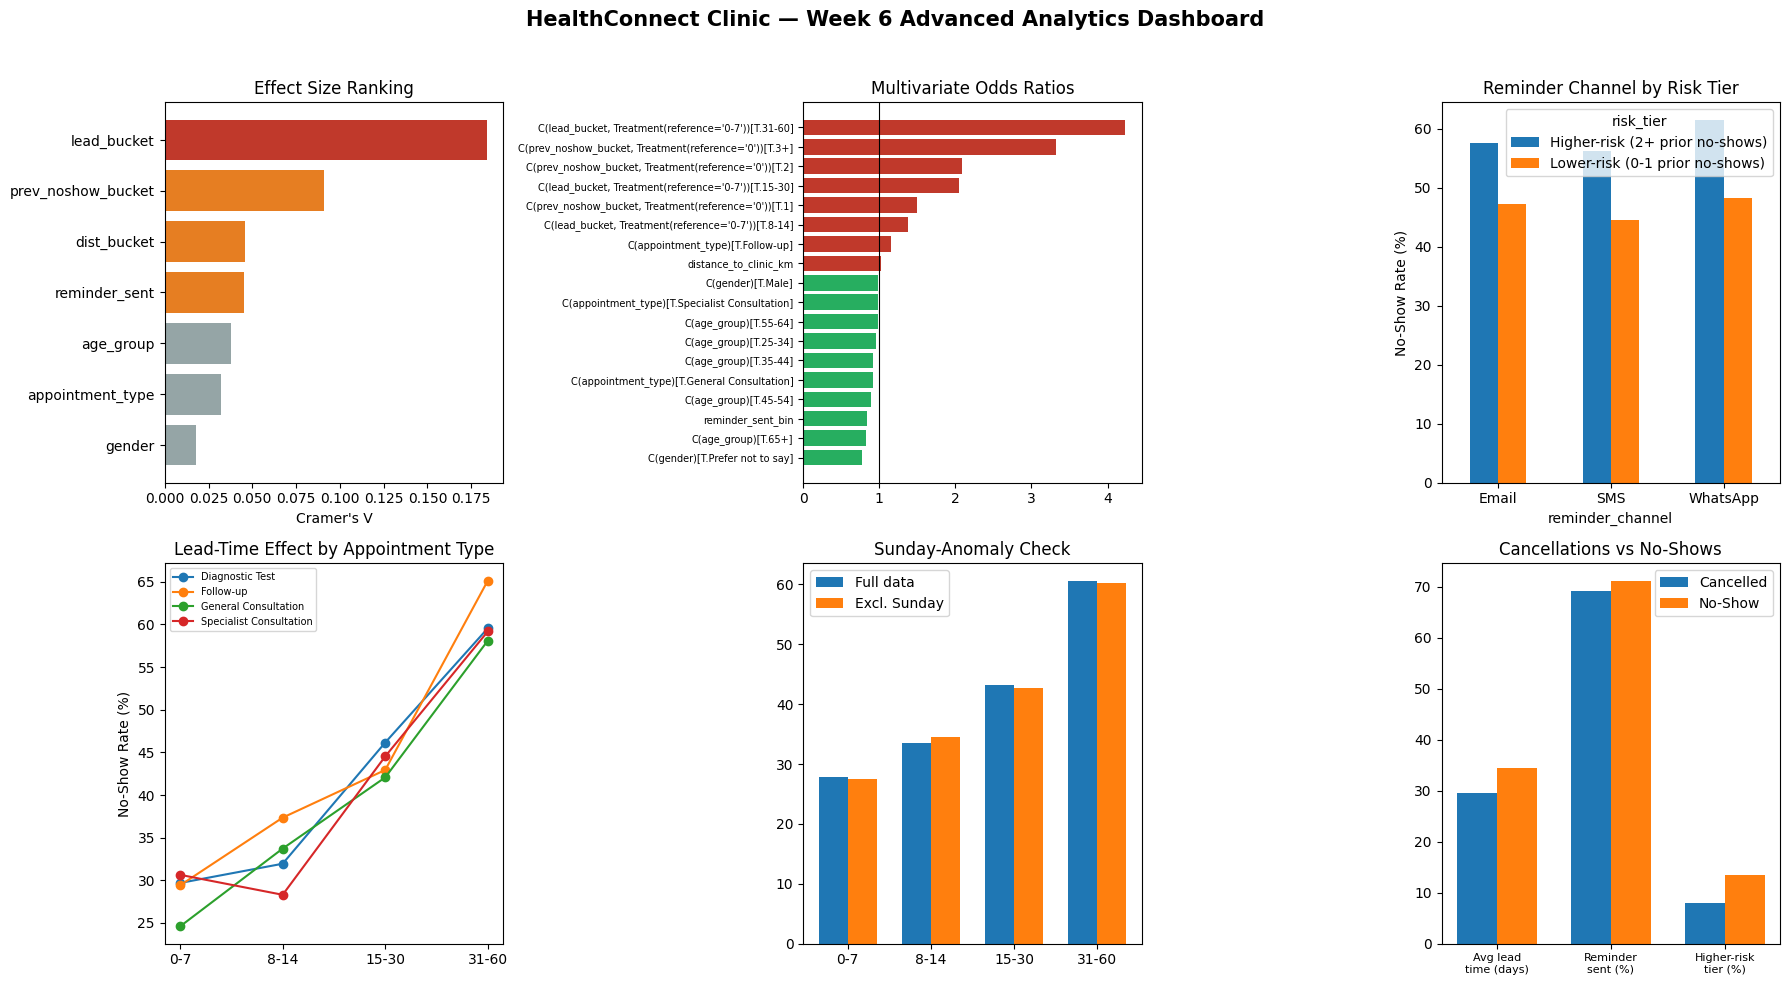

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('HealthConnect Clinic — Week 6 Advanced Analytics Dashboard', fontsize=15, fontweight='bold')

# Panel 1: Effect size ranking
ax = axes[0,0]
eff_sorted = eff.set_index('factor')['cramers_v']
colors = ['#c0392b' if v>0.1 else ('#e67e22' if v>0.04 else '#95a5a6') for v in eff_sorted]
ax.barh(eff_sorted.index[::-1], eff_sorted.values[::-1], color=colors[::-1])
ax.set_xlabel("Cramer's V"); ax.set_title('Effect Size Ranking')

# Panel 2: Odds ratios
ax = axes[0,1]
or_show = odds.drop('Intercept')['OR'].sort_values()
colors2 = ['#27ae60' if v<1 else '#c0392b' for v in or_show]
ax.barh(range(len(or_show)), or_show.values, color=colors2)
ax.set_yticks(range(len(or_show))); ax.set_yticklabels(or_show.index, fontsize=7)
ax.axvline(1, color='black', linewidth=0.8); ax.set_title('Multivariate Odds Ratios')

# Panel 3: reminder channel by risk tier
ax = axes[0,2]
pivot = tab2['mean'].unstack()
pivot.T.plot(kind='bar', ax=ax)
ax.set_ylabel('No-Show Rate (%)'); ax.set_title('Reminder Channel by Risk Tier'); ax.tick_params(axis='x', rotation=0)

# Panel 4: lead time by appointment type
ax = axes[1,0]
tab_lt = df.groupby(['appointment_type','lead_bucket'])['is_noshow'].mean().unstack()[['0-7','8-14','15-30','31-60']]*100
for t in tab_lt.index:
    ax.plot(tab_lt.columns, tab_lt.loc[t], marker='o', label=t)
ax.set_ylabel('No-Show Rate (%)'); ax.set_title('Lead-Time Effect by Appointment Type'); ax.legend(fontsize=7)

# Panel 5: sunday sensitivity
ax = axes[1,1]
full = df.groupby('lead_bucket')['is_noshow'].mean()[['0-7','8-14','15-30','31-60']]*100
excl = no_sun.groupby('lead_bucket')['is_noshow'].mean()[['0-7','8-14','15-30','31-60']]*100
x = np.arange(4); w = 0.35
ax.bar(x-w/2, full, w, label='Full data'); ax.bar(x+w/2, excl, w, label='Excl. Sunday')
ax.set_xticks(x); ax.set_xticklabels(full.index); ax.set_title('Sunday-Anomaly Check'); ax.legend()

# Panel 6: cancellation vs no-show
ax = axes[1,2]
labels = ['Avg lead\ntime (days)', 'Reminder\nsent (%)', 'Higher-risk\ntier (%)']
canc_vals = [canc.booking_lead_days.mean(), (canc.reminder_sent=='Yes').mean()*100, (canc.risk_tier=='Higher-risk (2+ prior no-shows)').mean()*100]
noshow_vals = [noshow.booking_lead_days.mean(), (noshow.reminder_sent=='Yes').mean()*100, (noshow.risk_tier=='Higher-risk (2+ prior no-shows)').mean()*100]
x = np.arange(3)
ax.bar(x-w/2, canc_vals, w, label='Cancelled'); ax.bar(x+w/2, noshow_vals, w, label='No-Show')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8); ax.set_title('Cancellations vs No-Shows'); ax.legend()

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('week6_dashboard_notebook.png', dpi=120, bbox_inches='tight')
plt.show()